# Analysis and Visualization of Composite Diagnostics

**Author:** Mingshi Yang (mingshi3@illinois.edu)  
**Date:** 2026-01-16  

**Project:**  
*Characteristics of Midlatitude Cyclones under Climate Change in a Global Storm-Resolving Model*

**Description:**  
This notebook generates figures using composite-analysis-derived diagnostics,
including Figures 3–9 and associated Supplementary Information figures for
the manuscript. The workflow focuses on visualization and figure assembly,
with most composite calculations performed in preceding processing scripts.


In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
from numpy import dtype
from scipy import stats
from datetime import date
import collections
import cartopy.crs as ccrs
import os
from scipy.stats import circmean
import pickle
from scipy.ndimage import uniform_filter
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib import colors

In [2]:
track_dir = '/glade/work/mingshiy/XSHIELD/code_repository/data/tracks'
composites_derived_dir = '/glade/work/mingshiy/XSHIELD/code_repository/data/composites'

In [3]:
experiments = [ 'PIRE',
                'PIRE_CO2_1270ppmv',
                'PIRE_PLUS_4K',
                'PIRE_PLUS_4K_CO2_1270ppmv']

experiments_display = [ 'CTRL   ',
                '+CO₂   ',
                '+4K    ',
                '+4K+CO₂']

expnames = ['ERA5   '] + experiments_display

colorlist = ['gray','black','C0','C1','C3']

In [4]:
tk = []
idx = []
for exp in experiments:
    tk.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Tracks.txt'))
    idx.append(np.loadtxt(f'{track_dir}/TK2Y-{exp}/All_Indexes.txt'))

In [5]:
xplot = (np.arange(201)*25-2500) / 1000

Figure 3 and associated SI

In [6]:
# plot figure 3 using 2020-2021 data
data_95_file = f'{composites_derived_dir}/TK2Y-allexp_p95_uv925.npy'
if os.path.isfile(data_95_file):
    data_95 = [d for d in np.load(data_95_file)]
else:
    data = []
    for i, exp in enumerate(experiments):

        print(exp)
        d = tk[i]
        sel0 = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))

        expf = exp.replace("\n","")
        data.append(np.load(f'/glade/work/mingshiy/XSHIELD/data/Composites/TK2Y-{expf}_uv925.npy',mmap_mode='r')[sel0].astype(np.float32))
        data_95 = [np.nanpercentile(d,95,axis=(0)) for d in data]
        np.save(data_95_file,np.array(data_95))

In [7]:
mean_uv = np.load(f'{composites_derived_dir}/TK2Y-allexp_means_uv925_t.npy')
pval_uv = np.load(f'{composites_derived_dir}/TK2Y-allexp-ctrl_pvalue_uv925_t.npy')

In [8]:
mean_uv.shape, pval_uv.shape

((4, 201, 201), (3, 201, 201))

Bbox(x0=0.125, y0=0.13397515527950304, x1=0.29347826086956524, y1=0.856024844720497)


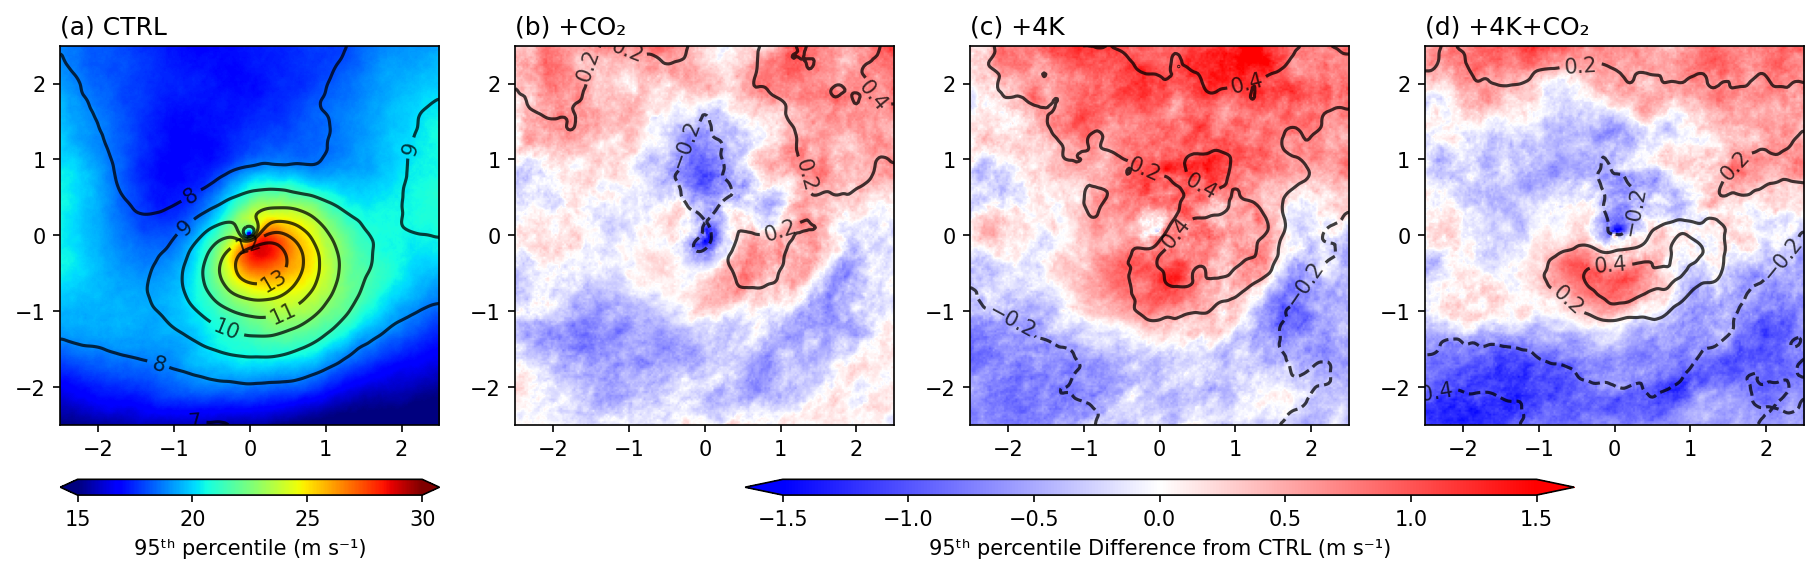

In [9]:
letters = 'abcdefg'
fig,axesall = plt.subplots(1,4,figsize=(15,3.5),dpi=150)
ax = axesall[0]
ct = ax.contour(xplot,xplot[::-1],uniform_filter(mean_uv[0],5),colors='black',
levels=None,alpha=0.75)
ax.clabel(ct)
im = ax.imshow(data_95[0],cmap='jet',vmin=15,vmax=30,extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
#ax.set_xticks([])
#ax.set_yticks([])
ax.set_title(f'({letters[0]}) '+experiments_display[0],loc='left')

bbox = ax.get_position()
print(bbox)
cbar_ax = fig.add_axes([bbox.x0, 0, bbox.x1-bbox.x0, 0.03])
cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('95ᵗʰ percentile (m s⁻¹)')

axes = axesall[1:]
for i, p in enumerate(pval_uv):
    mask = p.copy()*0+1
    mask[np.where(p>0.05)] = np.nan
    ct = axes[i].contour(xplot,xplot[::-1],uniform_filter(mean_uv[i+1]-mean_uv[0],5)*mask,colors='black',
        levels=[x for x in np.linspace(-0.6,0.6,7) if x != 0],alpha=0.75)
    axes[i].clabel(ct)
    im = axes[i].imshow(data_95[i+1]-data_95[0],cmap='bwr',vmin=-1.5,vmax=1.5,extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
    #axes[i].set_xticks([])
    #axes[i].set_yticks([])
    axes[i].set_title(f'({letters[i+1]}) '+experiments_display[i+1],loc='left')

    if i == 0:
        bbox = axes[i+1].get_position()

        cbar_ax = fig.add_axes([bbox.x0-0.1, 0, bbox.x1-bbox.x0+0.2, 0.03])
        cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
        cb.set_label('95ᵗʰ percentile Difference from CTRL (m s⁻¹)')
        #cbar_ax.set_xticks([-0.08,-0.06,-0.04,-0.02,0,0.06,0.12,0.18,0.24])

plt.show()

In [10]:
# Figure 3 using 2021 data (Figure S6)
data_95_file = f'{composites_derived_dir}/TK2Y2021-allexp_p95_uv925.npy'
if os.path.isfile(data_95_file):
    data_95 = [d for d in np.load(data_95_file)]
else:
    data = []
    for i, exp in enumerate(experiments):

        print(exp)
        d = tk[i]
        sel0 = np.array((d[:,0]>2021000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))

        expf = exp.replace("\n","")
        data.append(np.load(f'/glade/work/mingshiy/XSHIELD/data/Composites/TK2Y-{expf}_uv925.npy',mmap_mode='r')[sel0].astype(np.float32))
        data_95 = [np.nanpercentile(d,95,axis=(0)) for d in data]
        np.save(data_95_file,np.array(data_95))

In [11]:
mean_uv = np.load(f'{composites_derived_dir}/TK2Y2021-allexp_means_uv925_t.npy')
pval_uv = np.load(f'{composites_derived_dir}/TK2Y2021-allexp-ctrl_pvalue_uv925_t.npy')

Bbox(x0=0.125, y0=0.13397515527950304, x1=0.29347826086956524, y1=0.856024844720497)


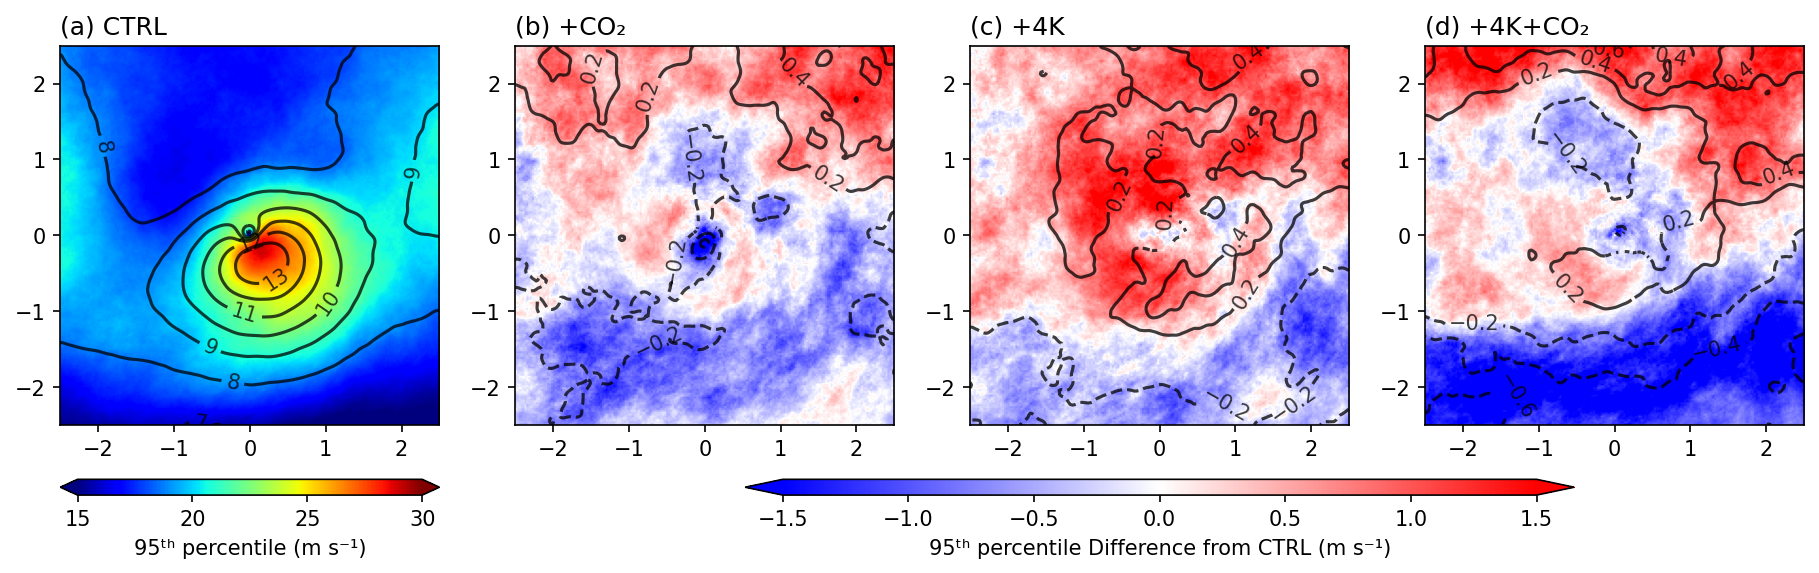

In [12]:
letters = 'abcdefg'
fig,axesall = plt.subplots(1,4,figsize=(15,3.5),dpi=150)
ax = axesall[0]
ct = ax.contour(xplot,xplot[::-1],uniform_filter(mean_uv[0],5),colors='black',
levels=None,alpha=0.75)
ax.clabel(ct)
im = ax.imshow(data_95[0],cmap='jet',vmin=15,vmax=30,extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
#ax.set_xticks([])
#ax.set_yticks([])
ax.set_title(f'({letters[0]}) '+experiments_display[0],loc='left')

bbox = ax.get_position()
print(bbox)
cbar_ax = fig.add_axes([bbox.x0, 0, bbox.x1-bbox.x0, 0.03])
cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('95ᵗʰ percentile (m s⁻¹)')

axes = axesall[1:]
for i, p in enumerate(pval_uv):
    mask = p.copy()*0+1
    mask[np.where(p>0.05)] = np.nan
    ct = axes[i].contour(xplot,xplot[::-1],uniform_filter(mean_uv[i+1]-mean_uv[0],5)*mask,colors='black',
        levels=[x for x in np.linspace(-0.6,0.6,7) if x != 0],alpha=0.75)
    axes[i].clabel(ct)
    im = axes[i].imshow(data_95[i+1]-data_95[0],cmap='bwr',vmin=-1.5,vmax=1.5,extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
    #axes[i].set_xticks([])
    #axes[i].set_yticks([])
    axes[i].set_title(f'({letters[i+1]}) '+experiments_display[i+1],loc='left')

    if i == 0:
        bbox = axes[i+1].get_position()

        cbar_ax = fig.add_axes([bbox.x0-0.1, 0, bbox.x1-bbox.x0+0.2, 0.03])
        cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
        cb.set_label('95ᵗʰ percentile Difference from CTRL (m s⁻¹)')
        #cbar_ax.set_xticks([-0.08,-0.06,-0.04,-0.02,0,0.06,0.12,0.18,0.24])

plt.show()

In [13]:
# Figure 3 using 2020 data (FIgure S5)
data_95_file = f'{composites_derived_dir}/TK2Y2020-allexp_p95_uv925.npy'
if os.path.isfile(data_95_file):
    data_95 = [d for d in np.load(data_95_file)]
else:
    data = []
    for i, exp in enumerate(experiments):

        print(exp)
        d = tk[i]
        sel0 = np.array((d[:,0]>2020000000)&(d[:,0]<2021000000)&(d[:,1]<65)&(d[:,1]>=30))

        expf = exp.replace("\n","")
        data.append(np.load(f'/glade/work/mingshiy/XSHIELD/data/Composites/TK2Y-{expf}_uv925.npy',mmap_mode='r')[sel0].astype(np.float32))
        data_95 = [np.nanpercentile(d,95,axis=(0)) for d in data]
        np.save(data_95_file,np.array(data_95))

In [14]:
mean_uv = np.load(f'{composites_derived_dir}/TK2Y2020-allexp_means_uv925_t.npy')
pval_uv = np.load(f'{composites_derived_dir}/TK2Y2020-allexp-ctrl_pvalue_uv925_t.npy')

Bbox(x0=0.125, y0=0.13397515527950304, x1=0.29347826086956524, y1=0.856024844720497)


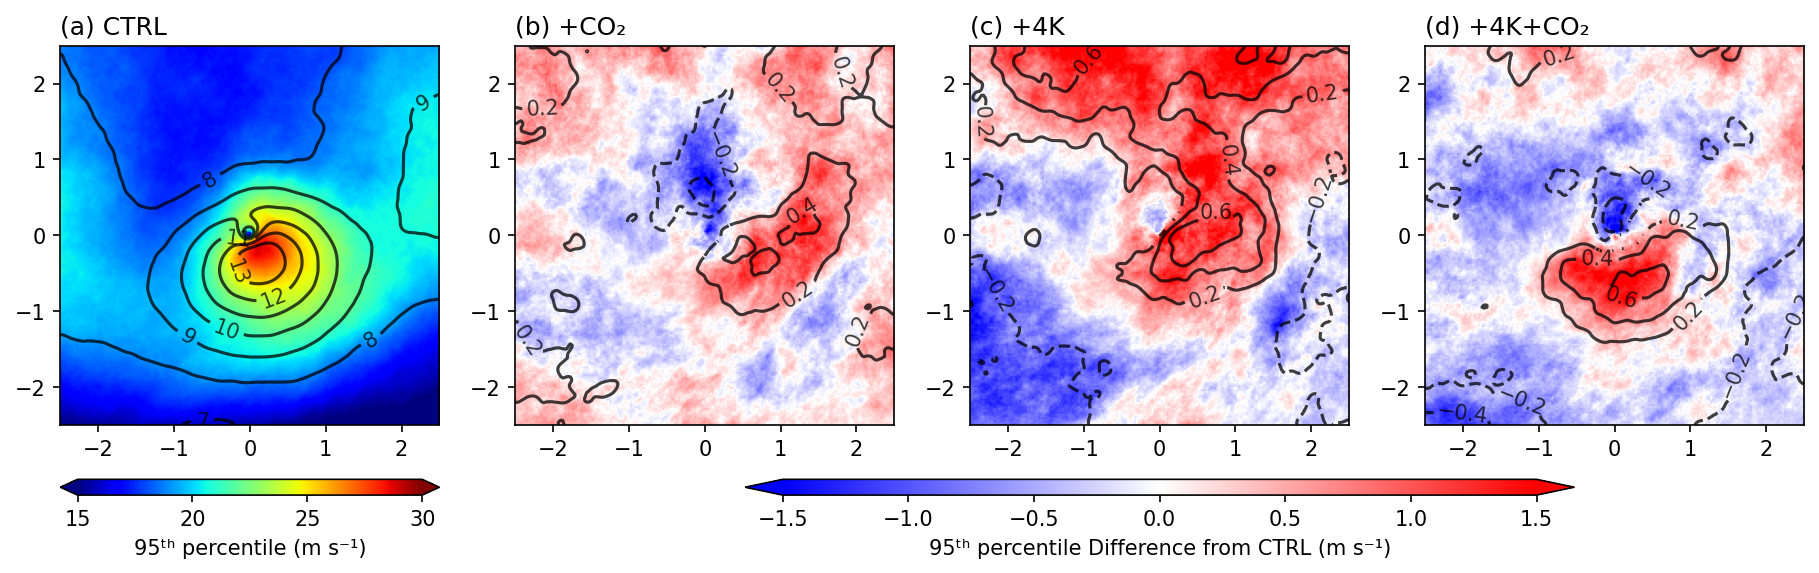

In [15]:
letters = 'abcdefg'
fig,axesall = plt.subplots(1,4,figsize=(15,3.5),dpi=150)
ax = axesall[0]
ct = ax.contour(xplot,xplot[::-1],uniform_filter(mean_uv[0],5),colors='black',
levels=None,alpha=0.75)
ax.clabel(ct)
im = ax.imshow(data_95[0],cmap='jet',vmin=15,vmax=30,extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
#ax.set_xticks([])
#ax.set_yticks([])
ax.set_title(f'({letters[0]}) '+experiments_display[0],loc='left')

bbox = ax.get_position()
print(bbox)
cbar_ax = fig.add_axes([bbox.x0, 0, bbox.x1-bbox.x0, 0.03])
cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('95ᵗʰ percentile (m s⁻¹)')

axes = axesall[1:]
for i, p in enumerate(pval_uv):
    mask = p.copy()*0+1
    mask[np.where(p>0.05)] = np.nan
    ct = axes[i].contour(xplot,xplot[::-1],uniform_filter(mean_uv[i+1]-mean_uv[0],5)*mask,colors='black',
        levels=[x for x in np.linspace(-0.6,0.6,7) if x != 0],alpha=0.75)
    axes[i].clabel(ct)
    im = axes[i].imshow(data_95[i+1]-data_95[0],cmap='bwr',vmin=-1.5,vmax=1.5,extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
    #axes[i].set_xticks([])
    #axes[i].set_yticks([])
    axes[i].set_title(f'({letters[i+1]}) '+experiments_display[i+1],loc='left')

    if i == 0:
        bbox = axes[i+1].get_position()

        cbar_ax = fig.add_axes([bbox.x0-0.1, 0, bbox.x1-bbox.x0+0.2, 0.03])
        cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
        cb.set_label('95ᵗʰ percentile Difference from CTRL (m s⁻¹)')
        #cbar_ax.set_xticks([-0.08,-0.06,-0.04,-0.02,0,0.06,0.12,0.18,0.24])

plt.show()

Figure 4

In [16]:
mean_pr = np.load(f'{composites_derived_dir}/TK2Y-allexp_means_PRATEsfc_t.npy')
pval_pr = np.load(f'{composites_derived_dir}/TK2Y-allexp-ctrl_pvalue_PRATEsfc_t.npy')

Bbox(x0=0.125, y0=0.13397515527950304, x1=0.29347826086956524, y1=0.856024844720497)


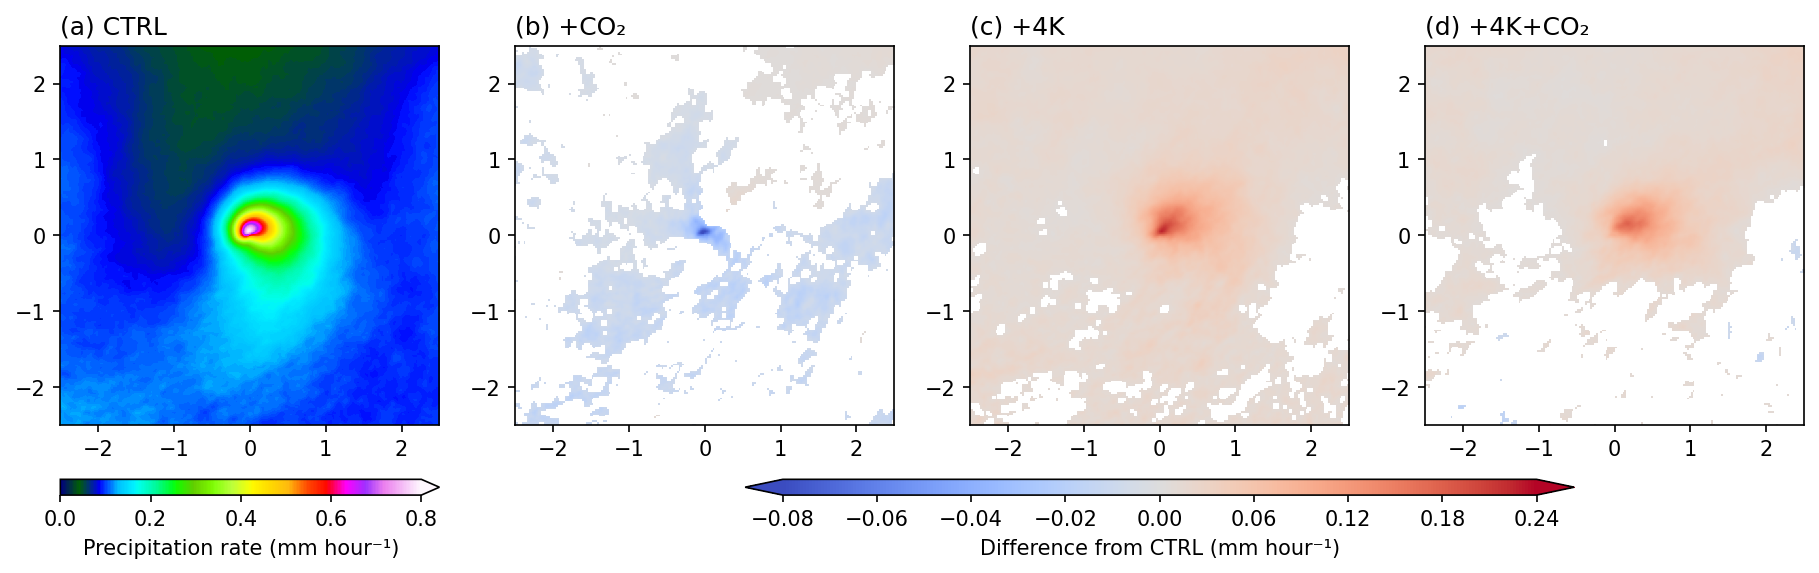

In [17]:
letters = 'abcdefg'
fig,axes = plt.subplots(1,4,figsize=(15,3.5),dpi=150)
for i, o in enumerate(mean_pr[:1]):
    im = axes[i].imshow(o*3600,vmin=0,vmax=0.8,cmap='gist_ncar',extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
    #plt.colorbar(im,ax=axes[i])
    #axes[i].contour(xplot,xplot,p,levels=(-1,0.05,999),colors='black')
    #axes[i].set_xticks([])
    #axes[i].set_yticks([])
    axes[i].set_title(f'({letters[i]}) '+experiments_display[i],loc='left')
bbox = axes[0].get_position()
print(bbox)
cbar_ax = fig.add_axes([bbox.x0, 0, bbox.x1-bbox.x0, 0.03])
cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='max')
cb.set_label('Precipitation rate (mm hour⁻¹)')
#plt.show()
#fig,axes = plt.subplots(1,3,figsize=(12,3))
for i, p in enumerate(pval_pr):
    mask = p.copy()*0+1
    mask[np.where(p>0.05)] = np.nan

    divnorm = colors.TwoSlopeNorm(vmin=-0.08, vcenter=0, vmax=0.24)


    im = axes[i+1].imshow((mean_pr[i+1]-mean_pr[0])*3600*mask,cmap='coolwarm', norm=divnorm,extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
    #plt.colorbar(im,ax=axes[i+1])
    #axes[i].contour(xplot,xplot,p,levels=(0.05,999),colors='black',alpha=0.4)
    #axes[i+1].set_xticks([])
    #axes[i+1].set_yticks([])
    axes[i+1].set_title(f'({letters[i+1]}) '+experiments_display[i+1],loc='left')
    
    if i == 1:
        
        bbox = axes[i+1].get_position()

        cbar_ax = fig.add_axes([bbox.x0-0.1, 0, bbox.x1-bbox.x0+0.2, 0.03])
        cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
        cb.set_label('Difference from CTRL (mm hour⁻¹)')
        cbar_ax.set_xticks([-0.08,-0.06,-0.04,-0.02,0,0.06,0.12,0.18,0.24])

plt.show()

Calculate and plot Figure 5

In [18]:
tk = []
idx = []
for exp in experiments:
    expf = exp.replace("\n","")
    tk.append(np.loadtxt(f'/glade/work/mingshiy/XSHIELD/tracks/TK2Y-{expf}/All_Tracks.txt'))
    idx.append(np.loadtxt(f'/glade/work/mingshiy/XSHIELD/tracks/TK2Y-{expf}/All_Indexes.txt'))

# circular mask, distance within r km is 1, outside is nan
def dmatrix(r,res):
    x = np.arange(-r,r+1e-10,res)
    y = x.copy()
    xx,yy = np.meshgrid(x,y)
    dm = np.ones_like(xx)
    dm[(xx**2+yy**2)>r**2] = np.nan
    return dm

dm250 = dmatrix(250,25)
dm500 = dmatrix(500,25)

presfc_250_file = f'{composites_derived_dir}/TK2Y-allexp_mean250_PRATEsfc.pkl'
if os.path.isfile(presfc_250_file):
    with open(presfc_250_file,'rb') as f:
        presfc_250 = pickle.load(f)
else:
    presfc_250 = []
    for i,exp in enumerate(experiments):
        d = tk[i]
        sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
        print('l')
        expf = exp.replace("\n","")
        data = np.load(f'/glade/work/mingshiy/XSHIELD/data/Composites/TK2Y-{expf}_PRATEsfc.npy')
        print('m')
        presfc_250.append(np.nanmean(data[sel][:,90:111,90:111]*dm250[None,:],axis=(-1,-2))) # use distance mask to calculate area average
        del data
    with open(presfc_250_file,'wb') as f:
        pickle.dump(presfc_250,f)

In [19]:
cwv_250_file = f'{composites_derived_dir}/TK2Y-allexp_mean250_cwv.pkl'
if os.path.isfile(cwv_250_file):
    with open(cwv_250_file,'rb') as f:
        cwv_250 = pickle.load(f)
else:
    cwv_250 = []
    for i,exp in enumerate(experiments):
        d = tk[i]
        sel = np.array((d[:,0]>2020000000)&(d[:,0]<2022000000)&(d[:,1]<65)&(d[:,1]>=30))
        print('l')
        expf = exp.replace("\n","")
        data = np.load(f'/glade/work/mingshiy/XSHIELD/data/Composites/TK2Y-{expf}_cwv.npy')
        print('m')
        cwv_250.append(np.nanmean(data[sel][:,90:111,90:111]*dm250[None,:],axis=(-1,-2)))
        del data
    with open(cwv_250_file,'wb') as f:
        pickle.dump(cwv_250,f)

Text(0.5, 0, '(mm)')

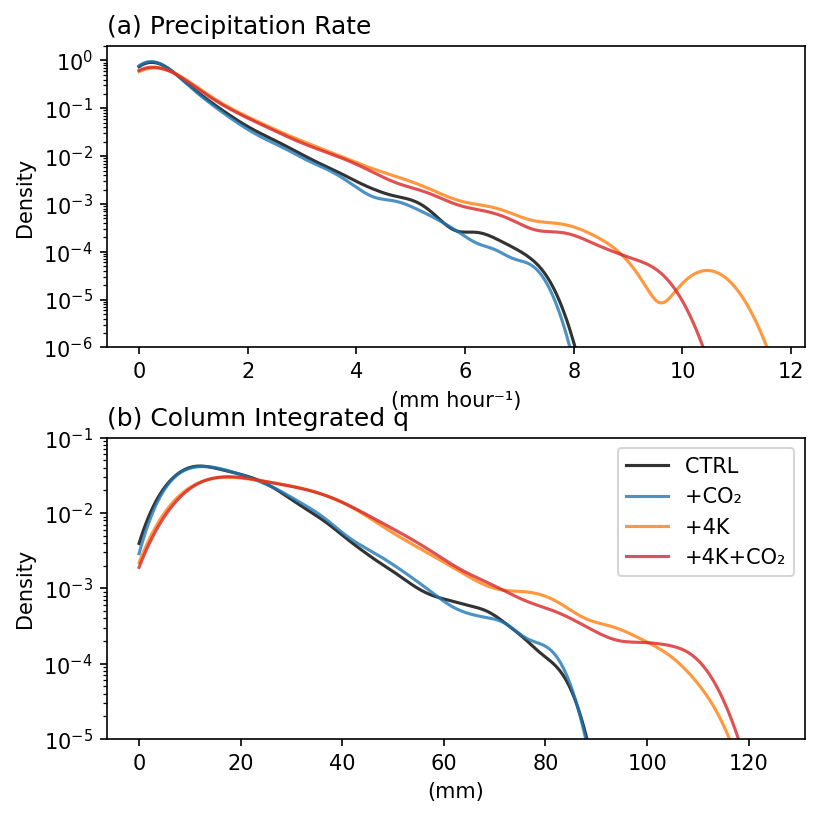

In [20]:
colorlist = ['gray','black','C0','C1','C3']
fig,axes = plt.subplots(2,1,dpi=150,figsize=(6,6))
fig.subplots_adjust(hspace=0.3)
for i, p250 in enumerate(presfc_250):
    sns.kdeplot(p250*3600,ax=axes[0],bw_adjust=4,clip=(0, np.inf),label=experiments_display[i],color=colorlist[i+1],alpha=0.8)
    
axes[0].set_yscale('log')
axes[0].set_ylim(1e-6,2e0)
axes[0].set_title('(a) Precipitation Rate',loc='left')
axes[0].set_xlabel('(mm hour⁻¹)')


for i, c250 in enumerate(cwv_250):
    sns.kdeplot(c250,ax=axes[1],bw_adjust=2,clip=(0, np.inf),label=experiments_display[i].replace("\n",""),color=colorlist[i+1],alpha=0.8)

axes[1].set_ylim(1e-5,1e-1)
axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_title('(b) Column Integrated q',loc='left')
axes[1].set_xlabel('(mm)')

Calculate KDE (probability density function estimate) and plot Figure 9

In [21]:
def get_kde_from_seaborn(data, bw_adjust, clip=None):
    temp_fig, temp_ax = plt.subplots()
    sns.kdeplot(data, bw_adjust=bw_adjust, clip=clip, ax=temp_ax, color='gray')
    line = temp_ax.lines[0]
    x, y = line.get_data()
    plt.close(temp_fig)
    return x, y

def plot_kde_with_mask(ax, x, y, label, color, count, threshold):
    x_space = x[1] - x[0]
    count_grid = y * count
    mask = count_grid < threshold
    ax.plot(x[~mask], y[~mask], label=label, color=color, linewidth=1,alpha=0.6)
    try:
        ax.plot(x/mask, y/mask, linestyle='--', color=color, linewidth=1,alpha=0.6)
    except:pass

In [22]:
# calculate area averaged omega first
var_name = 'omg'
levels = ['850','500','200']
levels = np.array([int(i) for i in levels])

omgdist = []

for i, exp in enumerate(experiments):
    exp = exp.replace("\n","")
    MC_idx = (tk[i][:,1]<65)&(tk[i][:,1]>=30)&(tk[i][:,0]>2020000000)&(tk[i][:,0]<2022000000)

    omglvl = []
    for level in levels:
        print(level)
        omg_500_file = f'{composites_derived_dir}/TK2Y-{exp}_mean500_{var_name}{level}.npy'
        if os.path.isfile(omg_500_file):
            datam = np.load(omg_500_file)
        else:
            data = np.load(f'/glade/work/mingshiy/XSHIELD/data/Composites/TK2Y-{exp}_{var_name}{level}.npy')[MC_idx,80:121,80:121]
            data = data * dm500[None,:,:]
            datam = np.nanmean(data,axis=(-1,-2))
            np.save(omg_500_file,datam)
            del data
        omglvl.append(datam)
        
    omgdist.append(omglvl)


850
500
200
850
500
200
850
500
200
850
500
200


In [23]:
import warnings
warnings.filterwarnings('ignore')

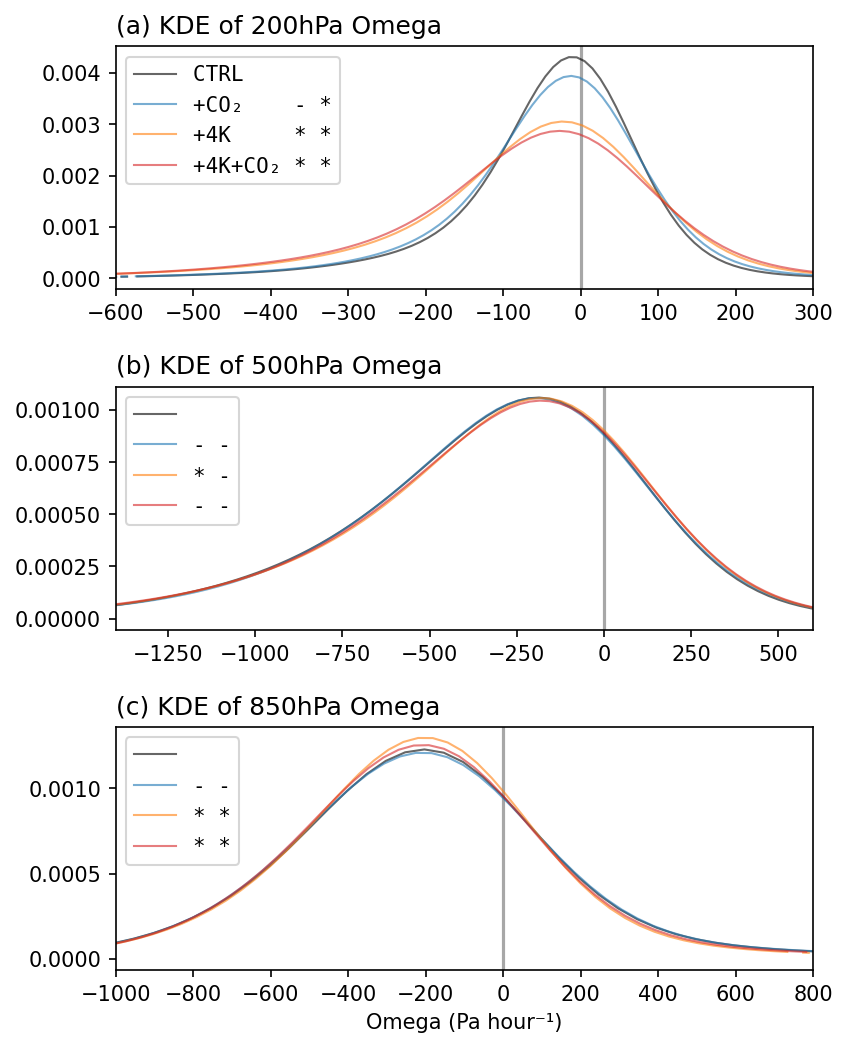

In [24]:
colorlist = ['gray','black','C0','C1','C3']
letters = 'abcdefg'
alpha=0.05

# parameters: estimate with increased smoothing to 4, and show area with estimated less than 1 cyclone per hPa/hour interval with dashed curve
bw = 4
threshold = 1

plotlevels = [850,500,200]

fig,axes = plt.subplots(3,1,figsize=(6,8),dpi=150)
for i in range(3):
    for j, exp in enumerate(experiments_display):
        exp = exp.replace("\n","")
        axes[2-i].axvline(0,color='gray',alpha=0.25,zorder=-10)
        sigs = ['','']

        x, y = get_kde_from_seaborn(omgdist[j][i]*3600, bw_adjust=bw)
        if j != 0:
            sigs = ['-','-']
            if stats.ttest_ind(omgdist[0][i], omgdist[j][i])[1] < alpha:
                sigs[0] = '*'
            if stats.levene(omgdist[0][i], omgdist[j][i])[1] < alpha:
                sigs[1] = '*'
        else:
            x0,y0 = x.copy(),y.copy()

        #sns.kdeplot(omgdist[j][i]*3600,ax=axes[2-i],label=f'{exp}'+' '+' '.join(sigs),bw_adjust=4,c=colorlist[j+1],alpha=0.75)
        if i == 2:
            llabel = f'{exp}'+' '+' '.join(sigs)
        else:
            llabel = ' '.join(sigs)
        plot_kde_with_mask(axes[2-i], x, y, label=llabel, color=colorlist[j+1], count=len(omgdist[j][i]), threshold=threshold)

        axes[2-i].set_title(f'({letters[2-i]}) KDE of '+str(plotlevels[i]) + 'hPa Omega',loc='left')
        #axes[i].set_yscale('log')
        #axes[i].set_ylim(1e-4,10)
        axes[2-i].legend(loc='upper left',prop={'family': 'monospace'})

axes[0].set_xlim(-600,300)
axes[1].set_xlim(-1400,600)
axes[2].set_xlim(-1000,800)
axes[2].set_xlabel('Omega (Pa hour⁻¹)')
plt.subplots_adjust(hspace=0.4)

Show a snapshot of 500 hPa omega in CTRL (all sample average; Figure S2)

In [25]:
mean_o500file = f'{composites_derived_dir}/TK2Y-PIRE_samplemean_omg500.npy'
if os.path.isfile(mean_o500file):
    mean_o5pire = np.load(mean_o500file)
else:
    mean_o5pire = np.load(f'/glade/work/mingshiy/XSHIELD/data/Composites/TK2Y-PIRE_omg500.npy').mean(axis=0)
    np.save(mean_o500file,mean_o5pire)

Bbox(x0=0.22375, y0=0.10999999999999999, x1=0.80125, y1=0.88)


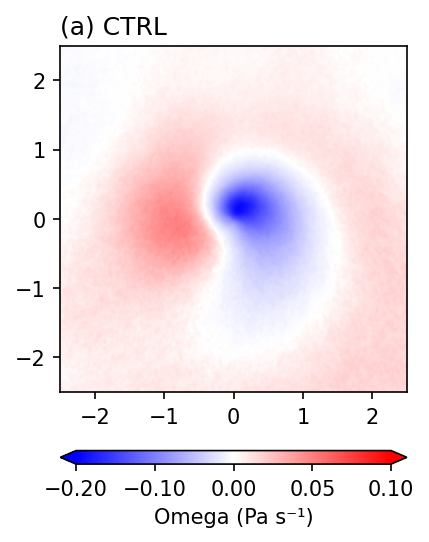

In [26]:
letters = 'abcdefg'
fig,ax = plt.subplots(figsize=(4,3),dpi=150)

im = ax.imshow(mean_o5pire,cmap='bwr',norm=colors.TwoSlopeNorm(vcenter=0,vmax=0.1,vmin=-0.2),extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
#plt.colorbar(im,ax=axes[i])
#axes[i].contour(np.arange(201),np.arange(201),p,levels=(-1,0.05,999),colors='black')
#ax.set_xticks([])
#ax.set_yticks([])
ax.set_title(f'(a) '+experiments_display[0],loc='left')
bbox = ax.get_position()
print(bbox)
cbar_ax = fig.add_axes([bbox.x0, -0.05, bbox.x1-bbox.x0, 0.03])
cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_ticks([-0.2,-0.1,0,0.05,0.1])
cb.set_label('Omega (Pa s⁻¹)')

Figure 6

In [27]:
mean_sta = np.load(f'{composites_derived_dir}/TK2Y-allexp_means_stability-thetae-200925_t.npy')
pval_sta = np.load(f'{composites_derived_dir}/TK2Y-allexp-ctrl_pvalue_stability-thetae-200925_t.npy')

In [28]:
def discretize(f,interval=5):
    i = 1/interval
    f2 = f.copy()
    f2 = np.round(f2*i)/i
    return f2

Bbox(x0=0.125, y0=0.13397515527950304, x1=0.29347826086956524, y1=0.856024844720497)


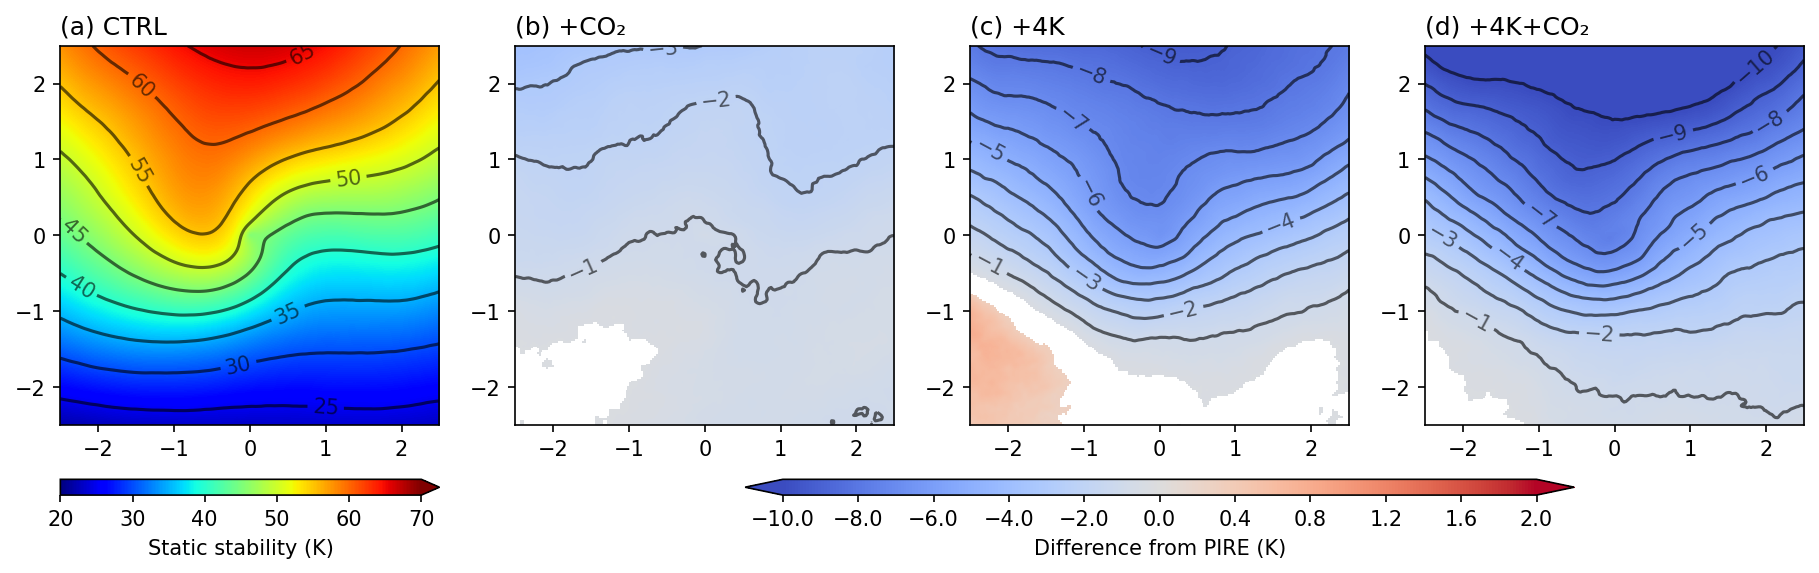

In [29]:
letters = 'abcdefg'
fig,axes = plt.subplots(1,4,figsize=(15,3.5),dpi=150)
for i, o in enumerate(mean_sta[:1]):
    
    c = axes[i].contour(xplot,xplot[::-1],o,levels = np.arange(20,71,5),colors='black',alpha=0.6)
    axes[i].clabel(c)
    im = axes[i].imshow(o,vmin=20,vmax=70,cmap='jet',extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
    #plt.colorbar(im,ax=axes[i])
    #axes[i].contour(xplot,xplot,p,levels=(-1,0.05,999),colors='black')
    #axes[i].set_xticks([])
    #axes[i].set_yticks([])
    axes[i].set_title(f'({letters[i]}) '+experiments_display[i],loc='left')
bbox = axes[0].get_position()
print(bbox)
cbar_ax = fig.add_axes([bbox.x0, 0, bbox.x1-bbox.x0, 0.03])
cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='max')
cb.set_label('Static stability (K)')
#plt.show()
#fig,axes = plt.subplots(1,3,figsize=(12,3))
for i, p in enumerate(pval_sta):
    mask = p.copy()*0+1
    mask[np.where(p>0.05)] = np.nan

    divnorm = None#colors.TwoSlopeNorm(vmin=-0.08, vcenter=0, vmax=0.24)
    divnorm = colors.TwoSlopeNorm(vmin=-10, vcenter=0, vmax=2)

    #im = axes[i+1].imshow((mean_pr[i+1]-mean_pr[0])*3600*mask,cmap='coolwarm', norm=divnorm)
    im = axes[i+1].imshow((mean_sta[i+1]-mean_sta[0])*mask,cmap='coolwarm', norm=divnorm,extent=[xplot[0], xplot[-1], xplot[0], xplot[-1]])
    c = axes[i+1].contour(xplot,xplot[::-1],(mean_sta[i+1]-mean_sta[0])*mask,levels = np.linspace(-10,2,13),colors='black',alpha=0.6,linestyles='solid')
    axes[i+1].clabel(c)
    #plt.colorbar(im,ax=axes[i+1])
    #axes[i].contour(xplot,xplot,p,levels=(0.05,999),colors='black',alpha=0.4)
    #axes[i+1].set_xticks([])
    #axes[i+1].set_yticks([])
    axes[i+1].set_title(f'({letters[i+1]}) '+experiments_display[i+1],loc='left')
    
    if i == 1:
        bbox = axes[i+1].get_position()

        cbar_ax = fig.add_axes([bbox.x0-0.1, 0, bbox.x1-bbox.x0+0.2, 0.03])
        cb = fig.colorbar(im,cax=cbar_ax,orientation='horizontal', extend='both')
        cb.set_label('Difference from PIRE (K)')
        #cbar_ax.set_xticks([-0.08,-0.06,-0.04,-0.02,0,0.06,0.12,0.18,0.24])
        cbar_ax.set_xticks([-10,-8,-6,-4,-2,0,0.4,0.8,1.2,1.6,2])

plt.show()

Obtain vertical cross sections and plot for Figures 7-8

In [30]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pandas as pd
from tqdm import tqdm

In [31]:
levels = [1000,925,850,700,500,200,50]

In [32]:
def dmatrix(r,res):
    x = np.arange(-r,r+1e-10,res)
    y = x.copy()
    xx,yy = np.meshgrid(x,y)
    dm = np.ones_like(xx)
    dm[(xx**2+yy**2)>r**2] = np.nan
    return dm

d2500 = dmatrix(2500,25)
d2500.shape

(201, 201)

In [33]:
# obtain the cross section
def get_cross_data(var_name,idx,iaxis):
    cross = np.zeros((4,len(levels),201))
    anom = np.zeros((4,len(levels),201))
    p = np.zeros((3,len(levels),201))
    for i, lvl in enumerate(levels):
        p_var = np.load(f'{composites_derived_dir}/TK2Y-allexp-ctrl_pvalue_{var_name}{lvl}_t.npy')
        p_var = np.take(p_var,idx,iaxis)
        mean_var = np.load(f'{composites_derived_dir}/TK2Y-allexp_means_{var_name}{lvl}_t.npy')
        anom_var = np.take(mean_var - np.nanmean(mean_var*d2500[None,:,:],axis=(-2,-1),keepdims=True),idx,iaxis)
        mean_var = np.take(mean_var,idx,iaxis)
        cross[:,i] = mean_var
        anom[:,i] = anom_var
        p[:,i] = p_var
    return cross, anom, p

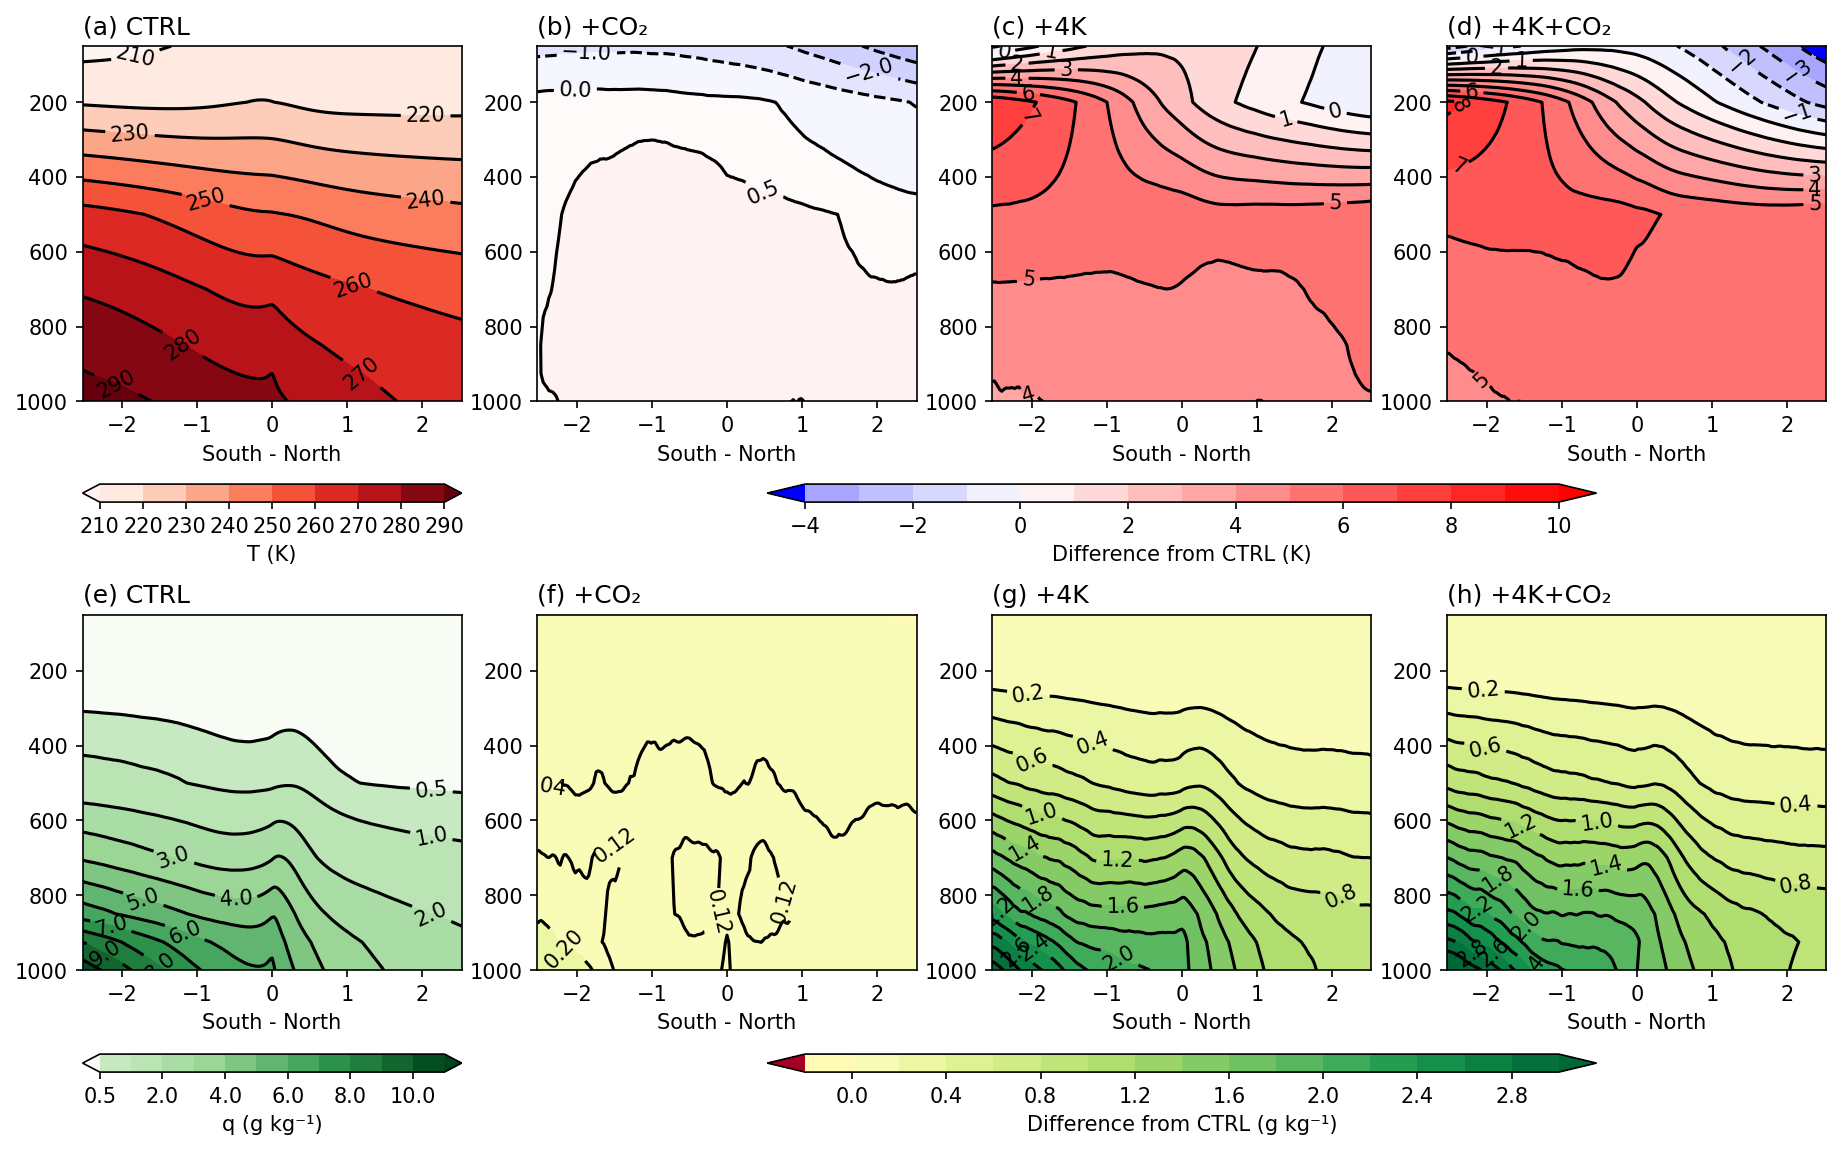

In [34]:
letters = 'abcdefghijkl'
cross, anom, p = get_cross_data('t',100,-1) # -1 is SN cross section, -2 is EW cross section
cross = cross[:,:,::-1]
anom = anom[:,:,::-1]
p = p[:,:,::-1]

fig,axes = plt.subplots(2,4,figsize=(15,8),dpi=150)

i = 0
lvl = np.arange(210,300,10)
cf00 = axes[0][i].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[0]),levels=lvl,cmap='Reds',extend='both')
c = axes[0][i].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[0]),levels=lvl,colors='black')

axes[0][i].clabel(c)
axes[0][i].invert_yaxis()
axes[0][i].set_title(f'({letters[i]}) '+experiments_display[i],loc='left')
axes[0][i].set_xlabel('South - North')

for i in range(1,4):
    mask = p[i-1].copy()*0+1
    mask[np.where(p[i-1]>0.05)] = np.nan

    sign = np.sign(cross[i] - cross[0])
    #p_new = p[i-1] * sign # between -0.05 and 0.05: significant
    p_new = (1-p[i-1]) * sign # <-0.95 or >0.95: significant
    signed_p = p_new
    
    if i != 1:
        cf0 = axes[0][i].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0]),levels=np.linspace(-4,10,15),cmap='bwr',extend='both',norm=colors.CenteredNorm())
        c = axes[0][i].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0]),levels=np.linspace(-4,10,15),colors='black',zorder=9)

    else:
        lvl = [-4,-3,-2,-1,0,0.5,1,1.5,14]
        cf0 = axes[0][i].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0]),levels=lvl,cmap='bwr',extend='both',norm=colors.CenteredNorm())
        c = axes[0][i].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0]),levels=lvl,colors='black',zorder=9)
    
    #c3 = axes[0][i].contour(np.linspace(-101,101,201)*25,levels,signed_p,levels=[-0.95,0.95],colors='purple',alpha=0.5,zorder=11,linestyles='solid')
    #c4 = axes[0][i].contourf(np.linspace(-101,101,201)*25,levels,signed_p,levels=[-0.95,0.95],colors='white',alpha=0.5,zorder=10)


    axes[0][i].clabel(c)
    axes[0][i].invert_yaxis()
    axes[0][i].set_title(f'({letters[i]}) '+experiments_display[i],loc='left')
    axes[0][i].set_xlabel('South - North')

bbox = axes[0][0].get_position()
yshift=0.03
cbar_ax = fig.add_axes([bbox.x0, bbox.y0-yshift, bbox.x1-bbox.x0, 0.015])
cb = fig.colorbar(cf00,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('T (K)')

bbox = axes[0][2].get_position()

cbar_ax = fig.add_axes([bbox.x0-0.1, bbox.y0-yshift, bbox.x1-bbox.x0+0.2, 0.015])
cb = fig.colorbar(cf0,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('Difference from CTRL (K)')

cross, anom, p = get_cross_data('q',100,-1) # -1 is SN cross section, -2 is EW cross section
cross = cross[:,:,::-1]
anom = anom[:,:,::-1]
p = p[:,:,::-1]

orig_cmap = plt.get_cmap('Greens')

# Create a truncated colormap starting from 0.5 to 1.0
new_cmap = colors.LinearSegmentedColormap.from_list(
    'Greens_trunc', orig_cmap([0,0.05,0.1,0.2,0.4,0.7,1])
)

i = 0
lvl = [0.5] + list(range(1,12,1))
cf10 = axes[1][i].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[0])*1000,levels=lvl,cmap=new_cmap,extend='both',norm=colors.CenteredNorm())
c = axes[1][i].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[0])*1000,levels=lvl,colors='black')

axes[1][i].clabel(c)
axes[1][i].invert_yaxis()
axes[1][i].set_title(f'({letters[i+4]}) '+experiments_display[i],loc='left')
axes[1][i].set_xlabel('South - North')

for i in range(1,4):
    mask = p[i-1].copy()*0+1
    mask[np.where(p[i-1]>0.05)] = np.nan

    sign = np.sign(cross[i] - cross[0])
    #p_new = p[i-1] * sign # between -0.05 and 0.05: significant
    p_new = (1-p[i-1]) * sign # <-0.95 or >0.95: significant
    signed_p = p_new

    if i != 1:
        cf1 = axes[1][i].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0])*1000,levels=np.linspace(-0.0002,0.003,17)*1000,cmap='RdYlGn',extend='both',norm=colors.CenteredNorm())
        c2 = axes[1][i].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0])*1000,levels=np.linspace(-0.0002,0.003,17)*1000,colors='black',zorder=9)
    else:
        cf1 = axes[1][i].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0])*1000,levels=np.linspace(-0.0002,0.003,17)*1000,cmap='RdYlGn',extend='both',norm=colors.CenteredNorm())
        c2 = axes[1][i].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0])*1000,levels=np.linspace(-0.0002,0.0002,6)*1000,colors='black',zorder=9)
    
    #c3 = axes[1][i].contour(np.linspace(-101,101,201)*25,levels,signed_p,levels=[-0.95,0.95],colors='purple',alpha=0.5,zorder=11,linestyles='solid')
    #c4 = axes[1][i].contourf(np.linspace(-101,101,201)*25,levels,signed_p,levels=[-0.95,0.95],colors='white',alpha=0.5,zorder=10)

    axes[1][i].clabel(c2)

    axes[1][i].invert_yaxis()
    axes[1][i].set_title(f'({letters[i+4]}) '+experiments_display[i],loc='left')
    axes[1][i].set_xlabel('South - North')

bbox = axes[1][0].get_position()
yshift=0.085
cbar_ax = fig.add_axes([bbox.x0, bbox.y0-yshift, bbox.x1-bbox.x0, 0.015])
cb = fig.colorbar(cf10,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('q (g kg⁻¹)')

bbox = axes[1][2].get_position()

cbar_ax = fig.add_axes([bbox.x0-0.1, bbox.y0-yshift, bbox.x1-bbox.x0+0.2, 0.015])
cb = fig.colorbar(cf1,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('Difference from CTRL (g kg⁻¹)')

plt.subplots_adjust(hspace=0.6)
plt.show()

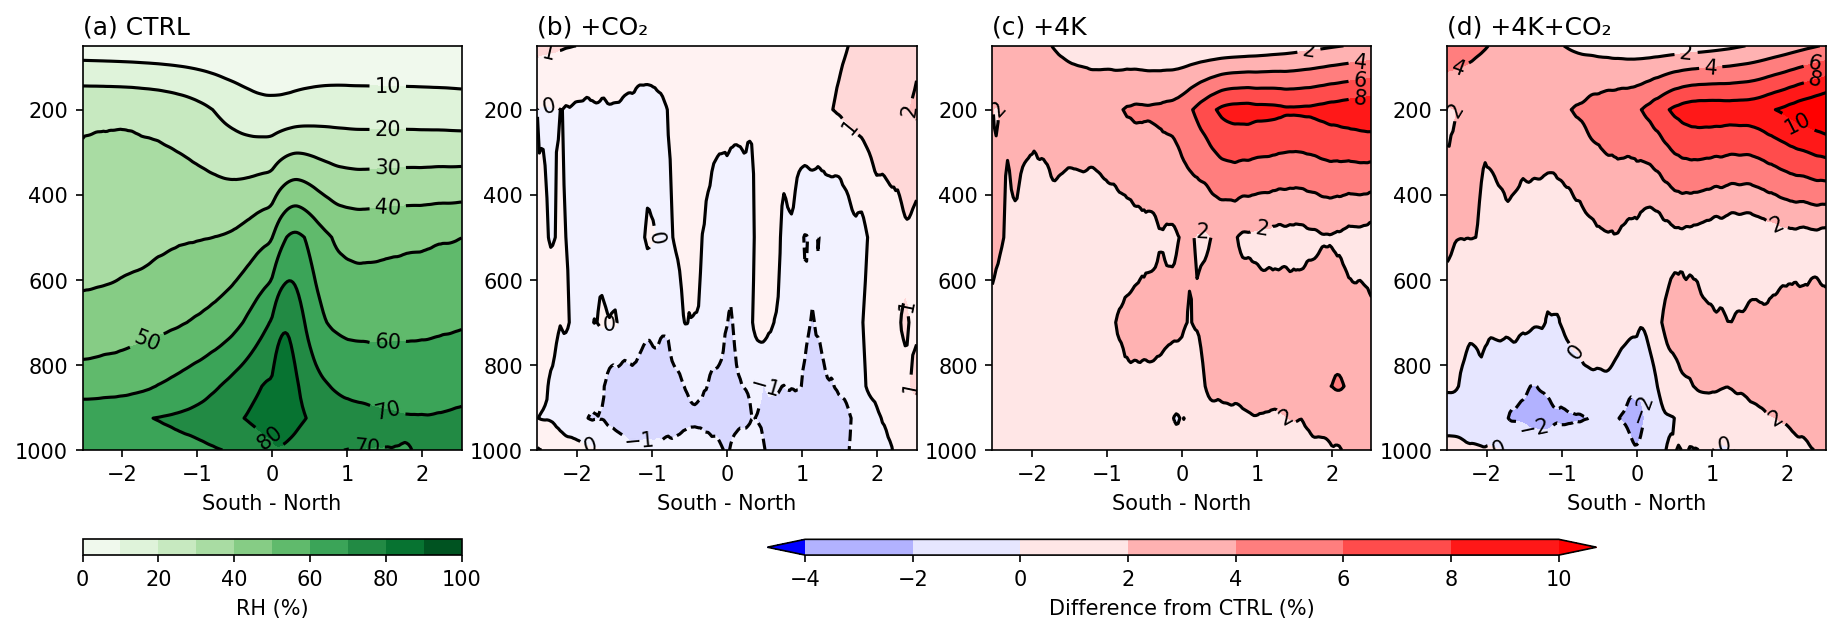

In [35]:
letters = 'abcdef'
cross, anom, p = get_cross_data('rh',100,-1) # -1 is SN cross section, -2 is EW cross section
cross = cross[:,:,::-1]
anom = anom[:,:,::-1]
p = p[:,:,::-1]

fig,axes = plt.subplots(1,4,figsize=(15,3.5),dpi=150)


i = 0
lvl = np.arange(0,101,10)
cf0 = axes[0].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[0]*100),levels=lvl,cmap='Greens',extend='neither')
c = axes[0].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[0]*100),levels=lvl,colors='black')

axes[0].clabel(c)
axes[0].invert_yaxis()
axes[0].set_title(f'({letters[i]}) '+experiments_display[i],loc='left')
axes[0].set_xlabel('South - North')


for i in range(1,4):
    mask = p[i-1].copy()*0+1
    mask[np.where(p[i-1]>0.05)] = np.nan

    mask2 = p[i-1].copy()*0+1
    mask2[np.where(p[i-1]<=0.05)] = np.nan

    sign = np.sign(cross[i] - cross[0])
    #p_new = p[i-1] * sign # between -0.05 and 0.05: significant
    p_new = (1-p[i-1]) * sign # <-0.95 or >0.95: significant
    signed_p = p_new

    if i != 1:
        cf = axes[i].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0])*100,levels=np.linspace(-4,10,8),cmap='bwr',extend='both',norm=colors.CenteredNorm())
        c2 = axes[i].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0])*100,levels=np.linspace(-4,10,8),colors='black',zorder=9)
        #c3 = axes[i].contour(np.linspace(-101,101,201)*25,levels,signed_p,levels=[-0.95,0.95],colors='purple',alpha=0.5,zorder=11,linestyles='solid')
        #c4 = axes[i].contourf(np.linspace(-101,101,201)*25,levels,signed_p,levels=[-0.95,0.95],colors='white',alpha=0.5,zorder=10)
    else:
        cf = axes[i].contourf(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0])*100,levels=np.linspace(-4,10,15),cmap='bwr',extend='both',norm=colors.CenteredNorm())
        c2 = axes[i].contour(np.linspace(-101,101,201)*25/1000,levels,(cross[i]-cross[0])*100,levels=np.linspace(-4,10,15),colors='black',zorder=9)
        #c3 = axes[i].contour(np.linspace(-101,101,201)*25,levels,signed_p,levels=[-0.95,0.95],colors='purple',alpha=0.5,zorder=11,linestyles='solid')
        #c4 = axes[i].contourf(np.linspace(-101,101,201)*25,levels,signed_p,levels=[-0.95,0.95],colors='white',alpha=0.5,zorder=10)
        #cf2 = axes[i].contourf(np.linspace(-101,101,201)*25,levels,mask2,colors='blue',zorder=10)
    
    axes[i].clabel(c2)

    axes[i].invert_yaxis()
    axes[i].set_title(f'({letters[i]}) '+experiments_display[i],loc='left')
    if i == 1:
        axes[i].set_xlabel('South - North')
    else:
        axes[i].set_xlabel('South - North')

bbox = axes[0].get_position()
yshift=0.2
cbar_ax = fig.add_axes([bbox.x0, bbox.y0-yshift, bbox.x1-bbox.x0, 0.03])
cb = fig.colorbar(cf0,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('RH (%)')

bbox = axes[2].get_position()

cbar_ax = fig.add_axes([bbox.x0-0.1, bbox.y0-yshift, bbox.x1-bbox.x0+0.2, 0.03])
cb = fig.colorbar(cf,cax=cbar_ax,orientation='horizontal', extend='both')
cb.set_label('Difference from CTRL (%)')

plt.show()